# **Multivariate and Combined Patterns:**  

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import dash
import warnings
warnings.filterwarnings('ignore')

In [2]:
data= pd.read_csv('data.csv')
data.shape

(42468, 14)

In [3]:
data.head(3)

,age,workclass,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,salary
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K


### **1. Workclass vs Education Level:**

In [4]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

In [5]:
data['workclass'].unique()  

array(['Private', 'Local-gov', 'Others', 'Self-emp-not-inc',
       'Federal-gov', 'State-gov', 'Self-emp-inc', 'Without-pay',
       'Never-worked'], dtype=object)

In [6]:
data["education"].unique()

array(['11th', 'HS-grad', 'Assoc-acdm', 'Some-college', '10th',
       'Prof-school', '7th-8th', 'Bachelors', 'Masters', 'Doctorate',
       '5th-6th', 'Assoc-voc', '9th', '12th', '1st-4th', 'Preschool'],
      dtype=object)

In [9]:
dass= data.groupby(by= "workclass")["education"].value_counts().reset_index()
dass

,workclass,education,count
0,Federal-gov,HS-grad,380
1,Federal-gov,Some-college,357
2,Federal-gov,Bachelors,303
3,Federal-gov,Masters,106
4,Federal-gov,Assoc-acdm,81
...,...,...,...
114,State-gov,Preschool,1
115,Without-pay,HS-grad,14
116,Without-pay,Some-college,3
117,Without-pay,7th-8th,2


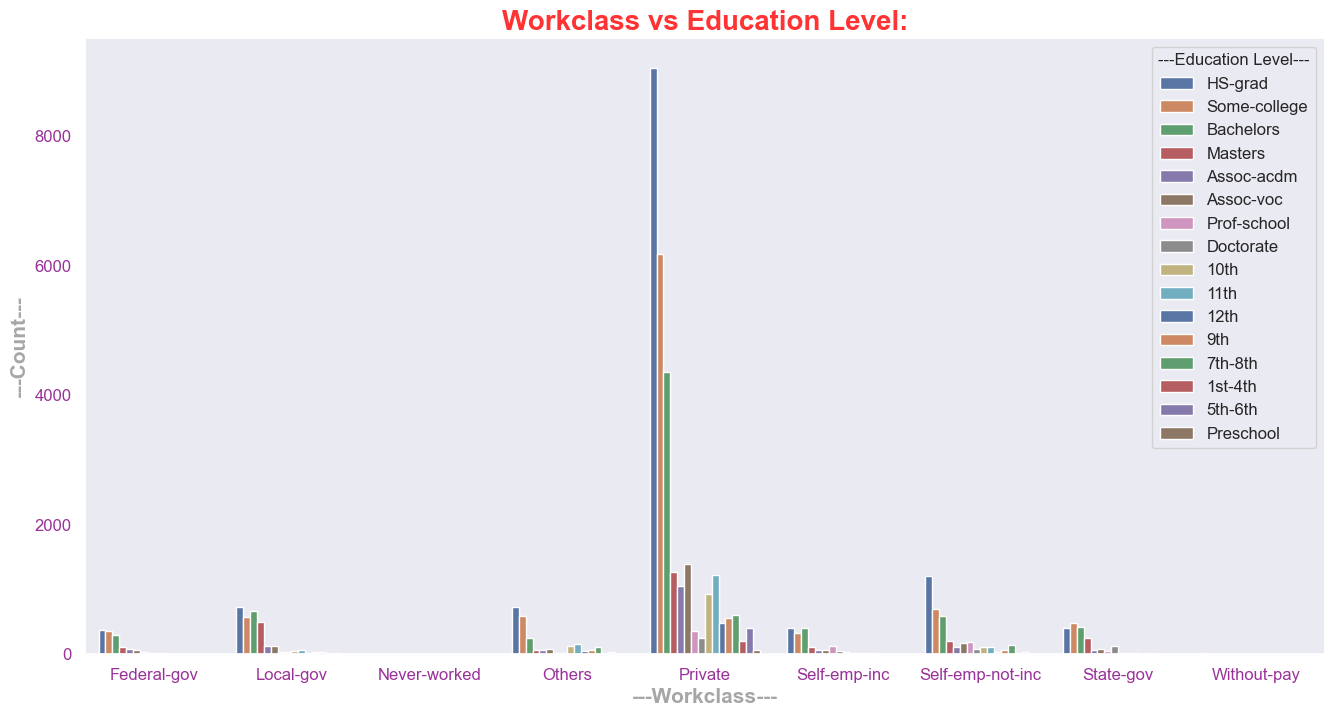

In [26]:
plt.figure(figsize= (16, 8))
sns.set_theme(style="dark", context="notebook", palette="pastel")
sns.barplot(data= dass, x= "workclass", y= "count", hue= "education", palette="deep")  
plt.title("Workclass vs Education Level:", fontsize= 20, fontweight= "bold", color= "red", alpha= 0.8)
plt.xlabel("---Workclass---", fontsize= 15, alpha= 0.7, fontweight= "bold", color= "gray")
plt.ylabel("---Count---", fontsize= 15, alpha= 0.7, fontweight= "bold", color= "gray")
plt.xticks(color= "purple", fontsize= 12, alpha= 0.8)
plt.yticks(color= "purple", fontsize= 12, alpha= 0.8)
plt.legend(title= "---Education Level---", title_fontsize= 12, fontsize= 12)
plt.show()

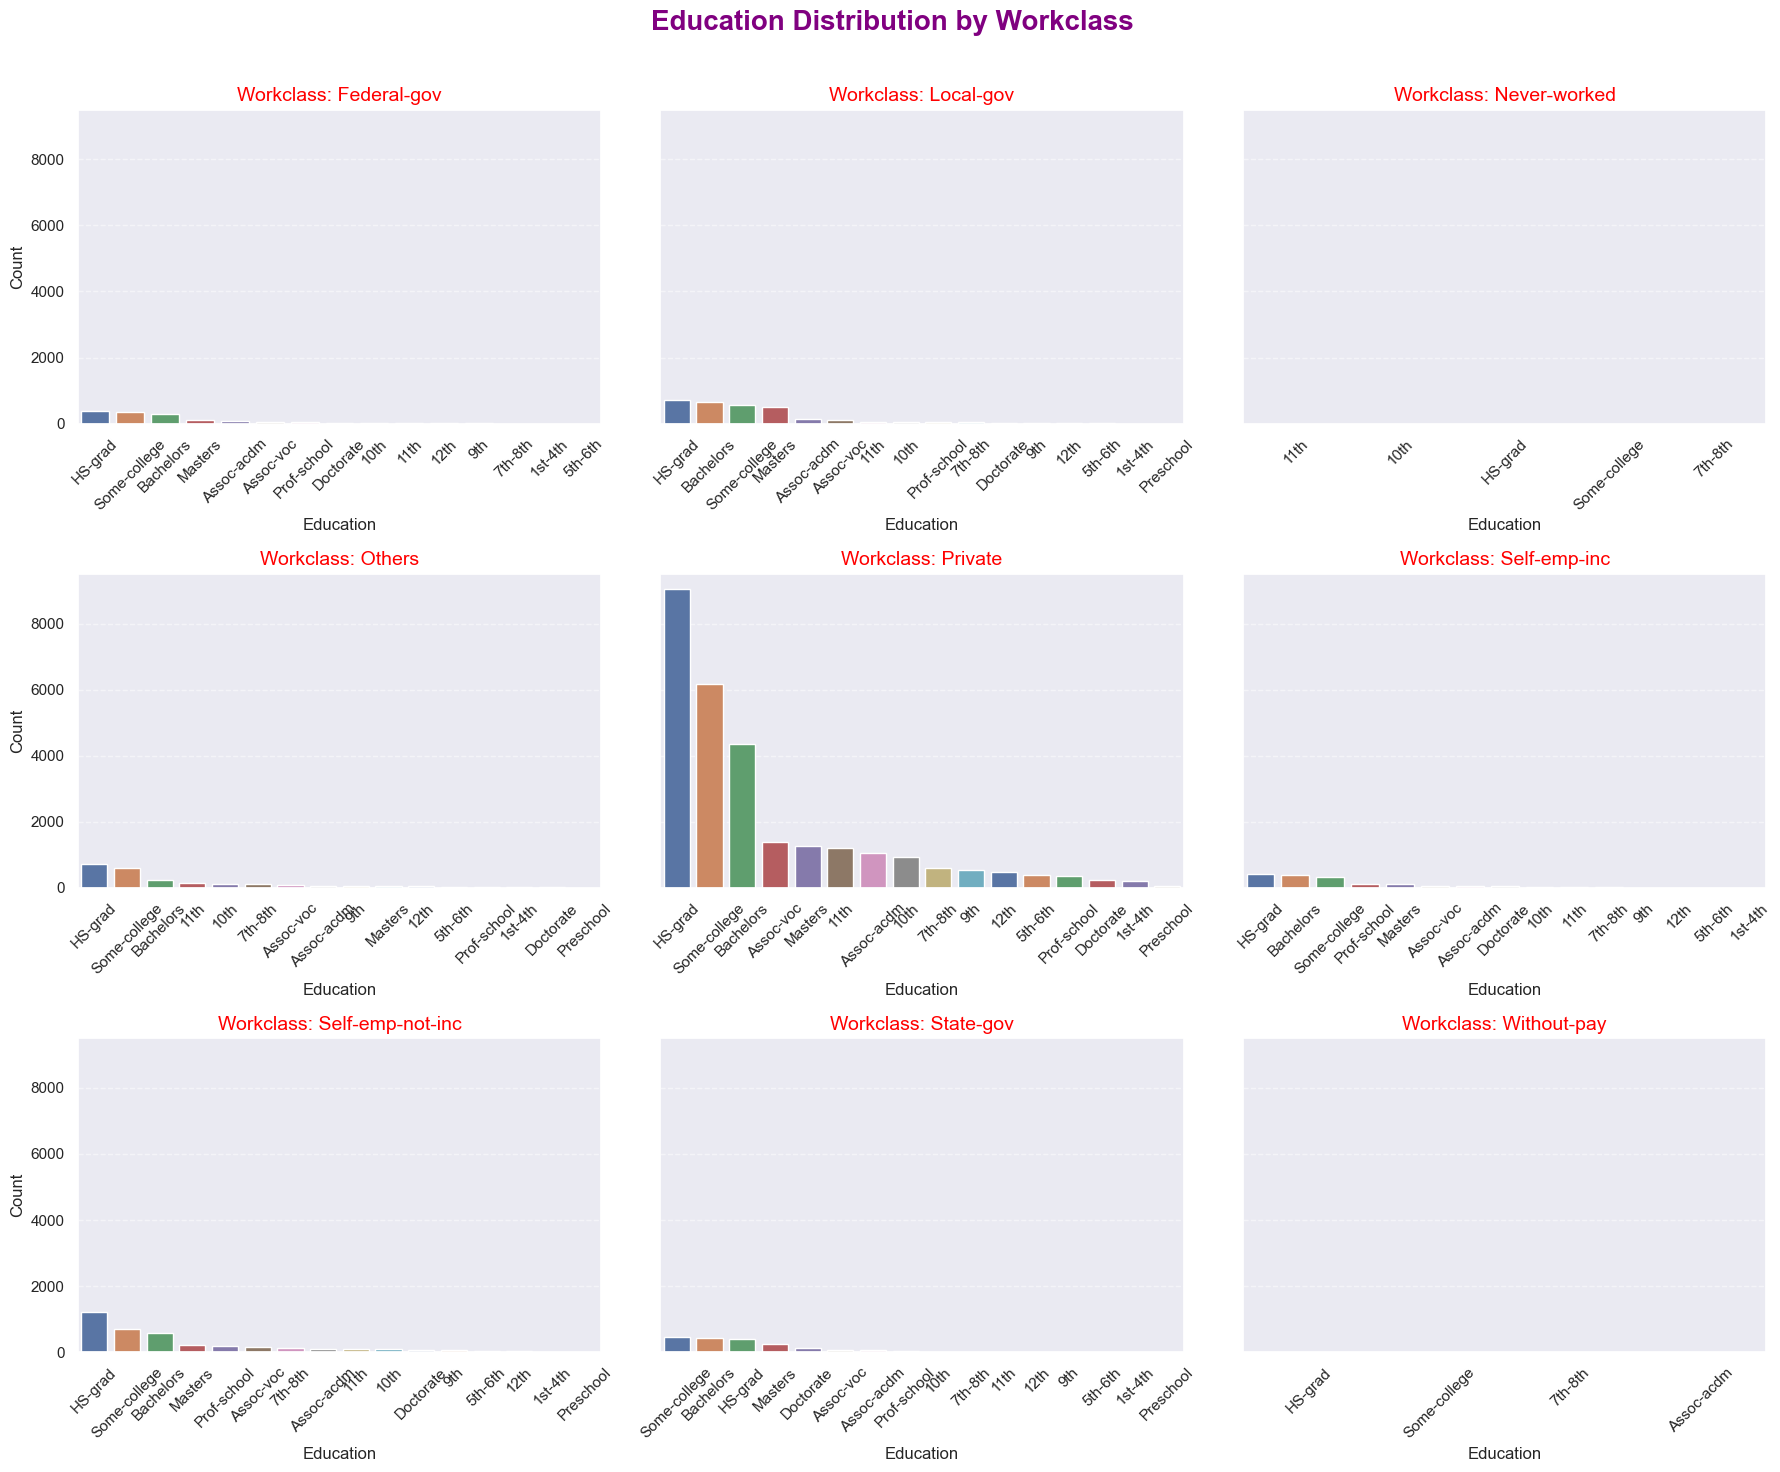

In [ ]:
# Get unique workclasses
workclasses = dass['workclass'].unique()
n_workclasses = len(workclasses)

# Set up subplots:
n_cols = 3 # number of columns 
n_rows = (n_workclasses + n_cols - 1) // n_cols # Number of rows 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows), sharey=True)
axes = axes.flatten()

for i, workclass in enumerate(workclasses):
    ax = axes[i]
    subset = dass[dass['workclass'] == workclass]
    sns.barplot(
        data=subset,
        x='education',
        y='count',
        ax=ax,
        palette='deep'
    )
    ax.set_title(f'Workclass: {workclass}', fontsize=14, color='red')
    ax.set_xlabel('Education', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# Remove empty subplots 
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Education Distribution by Workclass', fontsize=20, color='purple', fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [ ]:
# Pivot the data for heatmap
heatmap_data = dass.pivot(index='workclass', columns='education', values='count').fillna(0)

# How we did pivoting here: 
# workclass values become the row labels (index) of the new DataFrame
# education values become the column headers of the new DataFrame
# count values become the cell values in the pivot table
# Replaces any missing combinations with 0 if this situation occurs
heatmap_data

education,10th,11th,12th,1st-4th,5th-6th,7th-8th,9th,Assoc-acdm,Assoc-voc,Bachelors,Doctorate,HS-grad,Masters,Preschool,Prof-school,Some-college
workclass,,,,,,,,,,,,,,,,
Federal-gov,15.0,14.0,8.0,1.0,1.0,4.0,6.0,81.0,61.0,303.0,22.0,380.0,106.0,0.0,38.0,357.0
Local-gov,52.0,61.0,25.0,5.0,13.0,40.0,31.0,128.0,124.0,664.0,35.0,724.0,493.0,4.0,41.0,571.0
Never-worked,2.0,3.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,2.0
Others,123.0,161.0,56.0,18.0,41.0,108.0,68.0,71.0,83.0,245.0,18.0,726.0,66.0,10.0,24.0,593.0
Private,935.0,1215.0,476.0,198.0,398.0,603.0,552.0,1050.0,1390.0,4347.0,247.0,9053.0,1267.0,61.0,350.0,6170.0
Self-emp-inc,27.0,23.0,12.0,2.0,8.0,20.0,13.0,58.0,59.0,400.0,55.0,411.0,111.0,0.0,125.0,320.0
Self-emp-not-inc,104.0,106.0,30.0,16.0,33.0,137.0,57.0,110.0,169.0,590.0,76.0,1210.0,204.0,5.0,190.0,698.0
State-gov,19.0,15.0,11.0,2.0,4.0,16.0,10.0,63.0,75.0,418.0,123.0,399.0,252.0,1.0,45.0,474.0
Without-pay,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,14.0,0.0,0.0,0.0,3.0


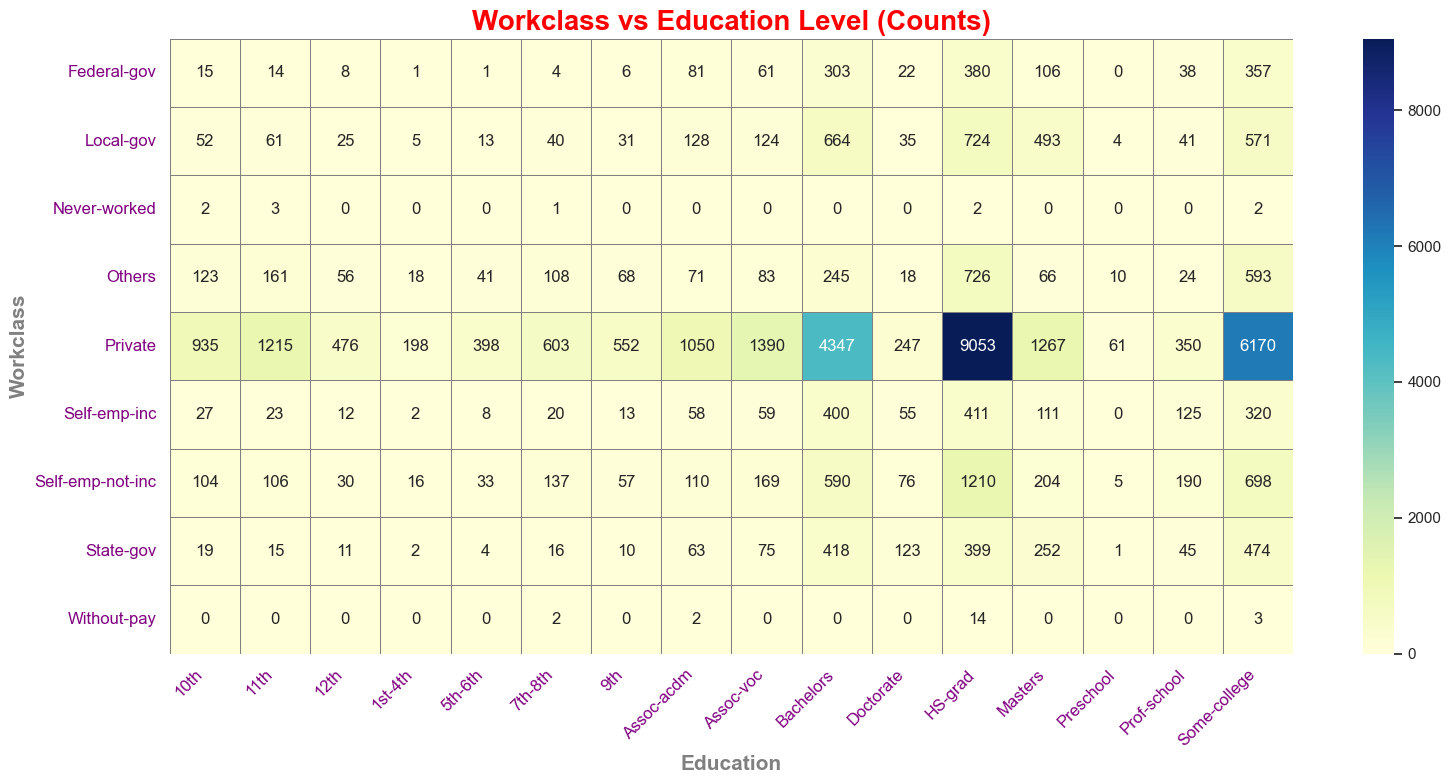

In [ ]:
plt.figure(figsize=(16, 8))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.0f', cmap='YlGnBu',
    linewidths=0.5, linecolor='gray'
)
plt.title('Workclass vs Education Level (Counts):', fontsize=20, color='red', fontweight='bold')
plt.xlabel('Education', fontsize=15, color='gray', fontweight='bold')
plt.ylabel('Workclass', fontsize=15, color='gray', fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12, color='purple')
plt.yticks(fontsize=12, color='purple')
plt.tight_layout()
plt.show()

• **`Private sector dominates`** - highest counts across education levels

• **`HS-grad most common`** - darkest blue shows highest frequency  

• **`Bachelors (College Degree) second popular`** - strong blue indicates high counts

• **`Masters well-represented`** - decent counts across work categories

• **`Government jobs favor`** - higher education (Bachelors, Masters)

• **`Self-employed mixed`** - across various education levels

• **`Advanced degrees rare`** - Doctorate, Preschool show low counts

• **`Never-worked minimal`** - very few people in category

• **`Without-pay negligible`** - almost zero across all education

• **`Private + HS-grad`** - largest single combination observed

---
---
---
---
---

### **2. Race vs Occupation:** 

In [37]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

In [44]:
dsa= data[["race", "occupation"]].value_counts().reset_index()
dsa.head(3)
das= dsa.pivot_table(values= "count", index= "occupation", columns= "race", fill_value= 0)
das

race,Amer-Indian-Eskimo,Asian-Pac-Islander,Black,Other,White
occupation,,,,,
Adm-clerical,54.0,198.0,703.0,43.0,3815.0
Armed-Forces,1.0,0.0,1.0,0.0,13.0
Craft-repair,61.0,118.0,354.0,58.0,4135.0
Exec-managerial,48.0,193.0,347.0,20.0,4804.0
Farming-fishing,14.0,23.0,56.0,14.0,1327.0
Handlers-cleaners,34.0,38.0,251.0,18.0,1397.0
Machine-op-inspct,28.0,84.0,404.0,47.0,1929.0
Other-service,61.0,183.0,797.0,51.0,3274.0
Others,35.0,96.0,320.0,31.0,1939.0


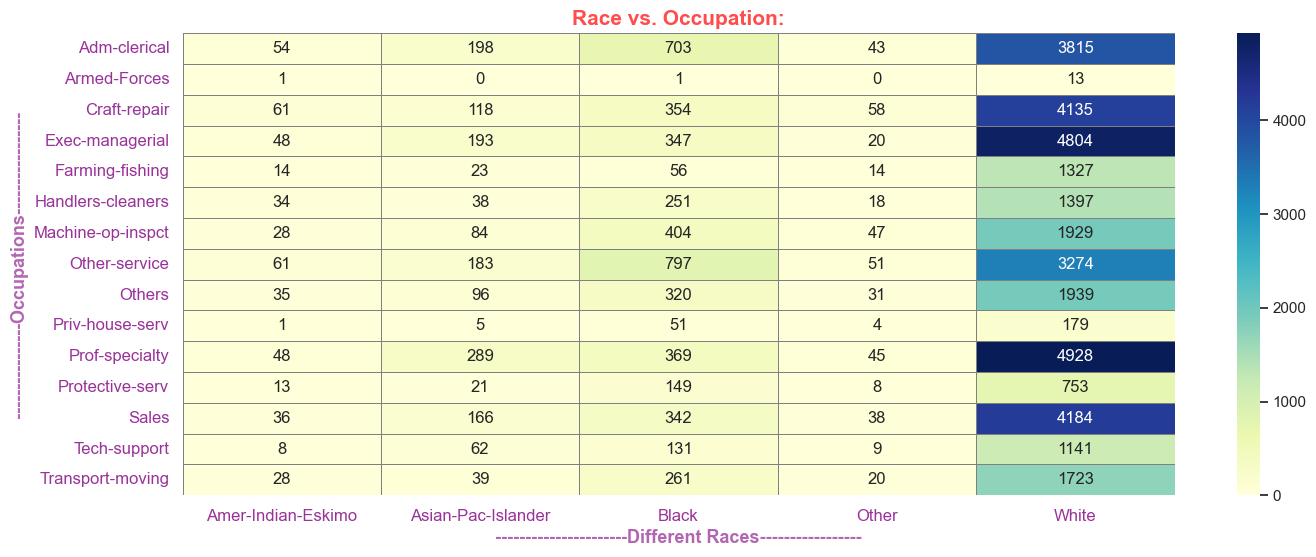

In [81]:
plt.figure(figsize= (16, 6))
sns.set_theme(style= "dark", context= "notebook", palette= "pastel")
sns.heatmap(data= das, cmap= "YlGnBu", annot= True, fmt= ".0f", linewidths= 0.5, linecolor= "gray")
plt.title("Race vs. Occupation:", fontsize= 15, fontweight= "bold", color= "Red", alpha= 0.7)
plt.xlabel("----------------------Different Races-----------------", fontsize= 13, fontweight= "bold", color= "purple", alpha= 0.6)
plt.ylabel("----------------Occupations-----------------", fontsize= 13, fontweight= "bold", color= "purple", alpha= 0.6)
plt.xticks(color= "purple", fontsize= 12, alpha= 0.8)
plt.yticks(color= "purple", fontsize= 12, alpha= 0.8)
plt.show()

* White race dominates all occupations.

* Highest White count: Prof-specialty (4928).

* Least represented: Armed-Forces, Priv-house-serv.

* Blacks mostly in Other-service, Adm-clerical.

* Asian-Pac-Islander strong in Prof-specialty.

* Amer-Indian-Eskimo numbers generally low.

* Other race mostly in Other-service, Adm-clerical.

* Protective-serv and Tech-support have low diversity.

* Farming-fishing least occupied overall.

* Race diversity highest in Prof-specialty and other services.

---
---
-----
----
-----
----

### **3. Country vs Income:** 

In [55]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'salary'],
      dtype='object')

In [59]:
mcp= data[["native-country", "salary"]].value_counts().reset_index()
mcp

,native-country,salary,count
0,United-States,<=50K,28035
1,United-States,>50K,9457
2,Mexico,<=50K,880
3,Others,<=50K,635
4,Others,>50K,218
...,...,...,...
78,Honduras,>50K,2
79,Trinadad&Tobago,>50K,2
80,Laos,>50K,2
81,Holand-Netherlands,<=50K,1


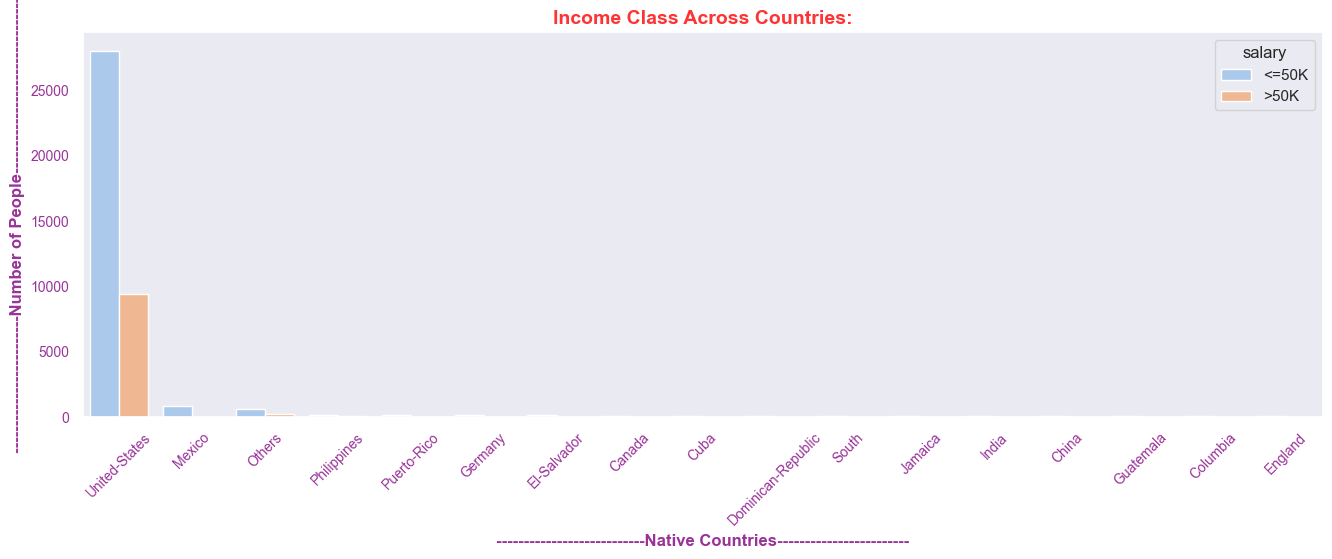

In [83]:
plt.figure(figsize= (16, 5))
sns.set_theme(style= "dark", context= "notebook", palette= "pastel")
sns.barplot(data= mcp.head(20), y= "count", x= "native-country", hue= "salary")
plt.title("Income Class Across Countries:", fontsize= 14, fontweight= "bold", color= "red", alpha= 0.8)
plt.xlabel("---------------------------Native Countries------------------------", fontsize= 12, fontweight= "bold", color= "purple", alpha= 0.8)
plt.ylabel("-------------------------Number of People--------------------------------", fontsize= 12, fontweight= "bold", color= "purple", alpha= 0.8)
plt.xticks(rotation= 45, fontsize= 10, color= "purple", alpha= 0.8)
plt.yticks(fontsize= 10, color= "purple", alpha= 0.8)
plt.show()

In [94]:
mcp= data[["native-country", "salary"]].value_counts().reset_index()
mcp= mcp.pivot_table(values= "count", index= "native-country", columns="salary", fill_value= 0).sort_values(by= ["<=50K", ">50K"], ascending= False)
mcp

salary,<=50K,>50K
native-country,,
United-States,28035.0,9457.0
Mexico,880.0,47.0
Others,635.0,218.0
Philippines,208.0,85.0
Puerto-Rico,164.0,20.0
Germany,148.0,58.0
El-Salvador,144.0,11.0
Canada,119.0,63.0
Cuba,104.0,34.0


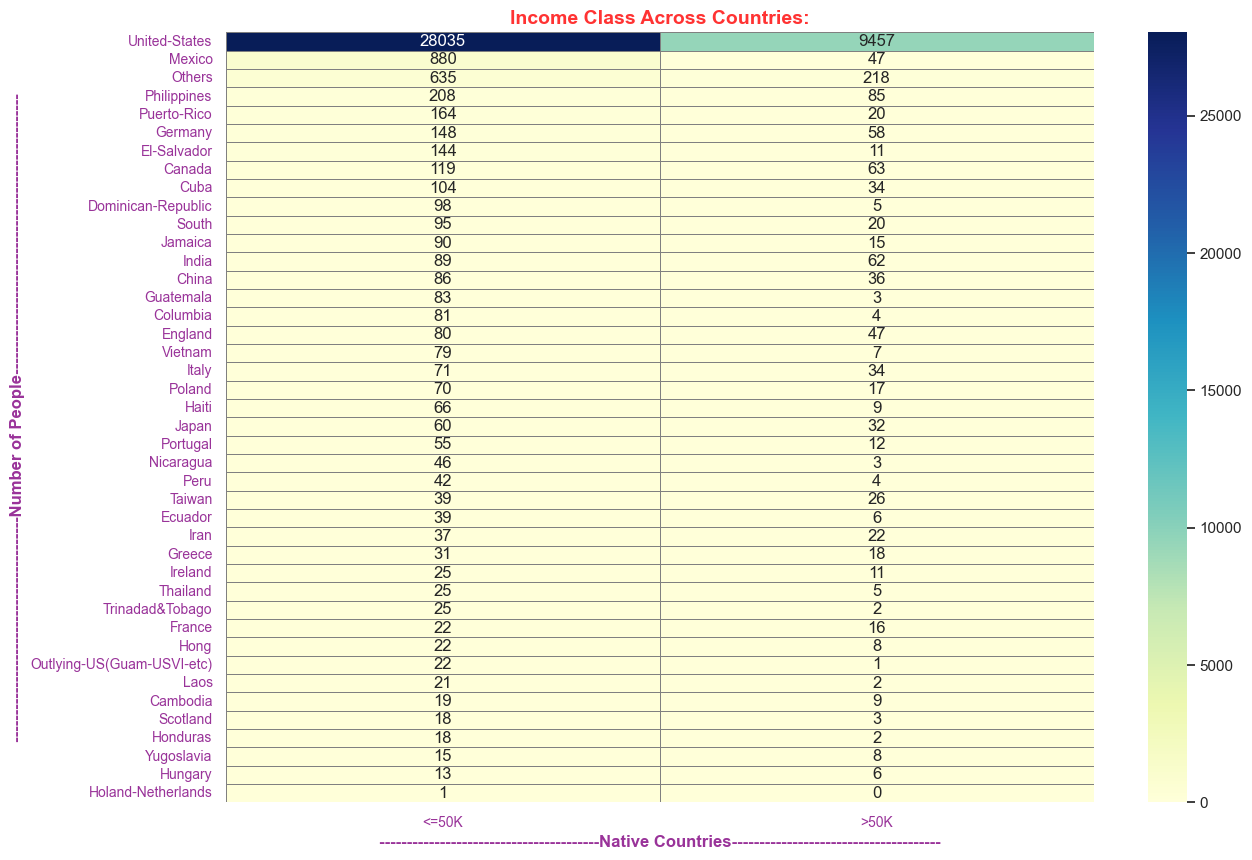

In [95]:
plt.figure(figsize= (14, 10))
sns.heatmap(data= mcp, cmap= "YlGnBu", annot= True, fmt= ".0f", linewidths= 0.5, linecolor= "gray")
plt.title("Income Class Across Countries:", fontsize= 14, fontweight= "bold", color= "red", alpha= 0.8)
plt.xlabel("----------------------------------------Native Countries--------------------------------------", fontsize= 12, fontweight= "bold", color= "purple", alpha= 0.8)
plt.ylabel("-----------------------------------------Number of People---------------------------------------------------", fontsize= 12, fontweight= "bold", color= "purple", alpha= 0.8)
plt.xticks(fontsize= 10, color= "purple", alpha= 0.8)
plt.yticks(fontsize= 10, color= "purple", alpha= 0.8)
plt.show()

* United States dominates both income classes.

* Mexico has mostly low-income individuals.

* India shows high proportion of >50K earners.

* England has strong high-income presence.

* Japan's high-income count is relatively high.

* Most countries skew towards ≤50K earners.

* Guatemala has very few high-income individuals.

* Canada has moderate income distribution.

* Germany has low but balanced income spread.

* Philippines mostly has low-income individuals.

* China shows few high-income people.

* El-Salvador and Haiti lack high earners.

* Holand-Netherlands has zero high-income individuals.

* High-income concentrated in developed countries.

-----
-----
-----
----
-----
---

### **4. Age vs Capital Gain vs Salary:**

Objective: Check how age and capital gain together affect income class.
How: Use a 2D scatter plot with age and capital-gain, color-coded by salary.